In [4]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.cm.tab20.colors  # 20 distinct colors
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


In [5]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            'spanish',
            'chinese',
            'german',
            'arabic',
            'turkish',
            'italian',
            ]

batch_shuffle = 0
centers_var = 'sem'
min_token_length = 3
n_files = 21
batch_size = 100
n_tokens = min_token_length
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var ='sem'
zero_activations_list = [0]
center_A_flags = [0]
center_B_flags = [0]

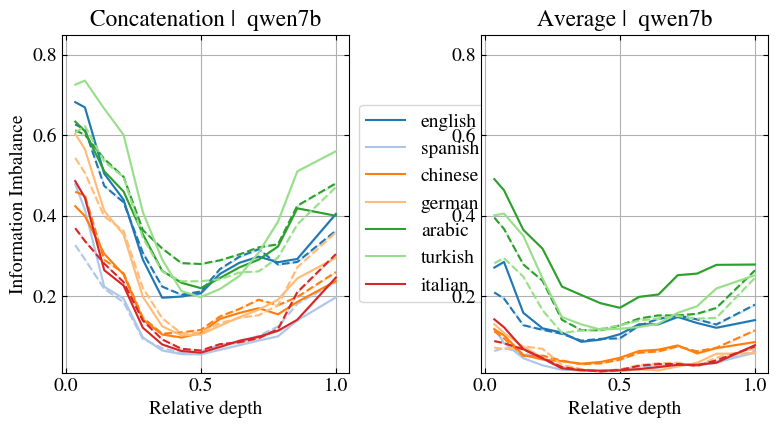

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(8,4.5))

for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  if avg_tokens:
    _n_tokens = -1
    _min_token_length = -1
  else:
    _n_tokens = n_tokens
    _min_token_length = min_token_length

  for number_of_languages in [None]:
    for zero_id,zero_activations in enumerate(zero_activations_list):
      for center_A_id,center_A_flag in enumerate(center_A_flags):
        for center_B_id,center_B_flag in enumerate(center_B_flags):

          if center_A_flag != center_B_flag: 
            continue
          if center_A_flag == 0 and number_of_languages != None:
            continue
          if center_A_flag != 0 and number_of_languages == None:
            continue
          
          for language_id, language in enumerate(languages):
              output_folder0 = makefolder(base=f'./results/',
                                          global_centering=0,
                                          spaces='AB',
                                          similarity_fn='normalized_L2_distance',
                                          precision=32,
                                          language=language,
                                          data_var=data_var,
                                          modelA=modelA,
                                          modelB=modelB,
                                          match_var=match_var,
                                          n_files=n_files,
                                          min_token_length=_min_token_length,
                                          )
              II_folder = makefolder(base=output_folder0,
                                                centers=centers_var,
                                                Nbits=Nbits,
                                                n_tokens=_n_tokens,
                                                avg_tokens=avg_tokens,
                                                batch_shuffle=batch_shuffle,
                                                zero_activations=zero_activations,
                                                center_A_flag=center_A_flag,
                                                center_B_flag=center_B_flag,
                                                number_of_languages=number_of_languages,
                                                )
              inf_imb = np.load(II_folder + "II.npy")
              std = np.load(II_folder + "II_jack_std.npy")

              layers_A = list(range(1,depths[modelA] + 1))
              layers_B = list(range(1,depths[modelB] + 1))
              layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
              layers /= depths[modelB]
              color = colors[plot_id] 
              linestyle = '-'
              if avg_tokens:
                title = f'Average | '
              else:
                title = f'Concatenation | '

              label = ''
              if center_A_flag == 0:
                label += f'{language}'
              for II_index in range(2):
                ax[avg_id].plot(layers,
                        inf_imb[II_index].diagonal(),
                        label=label if II_index == 0 else None,
                        linestyle=_linestyles[II_index],
                        color=color,
                        ) 
                ax[avg_id].fill_between(layers,
                                inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                alpha=0.2,
                                color=color,
                                )
              plot_id += 1

  ax[avg_id].set_xlabel('Relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')
  ax[avg_id].set_title(title + f' {modelA}')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(0.01,.85)
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/semantic_similarity_{modelA}.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()